# Import Libraries

e) Creating Visualizations and Explainable AI. (5 points)
1. Implement visualizations (e.g., scatter plots and line graphs) for your models' losses and
accuracies on training and validation datasets to analyze the convergence and overall
performance of the model.
2. Use Explainable AI techniques such as GradCAM to analyze what features in the image are
contributing the most and the least in the model's decision-making process. Please also
include a few visualization results in the report.


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import random

from torch.utils.data import DataLoader
from torchvision import models, transforms

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Use GPU device is possible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [ ]:
class SingleModels(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.backbone = models.resnet34(pretrained=False)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.fc(x)
        return x


# Grad-CAM

<ipython-input-15-e71bf48e3a76>:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('/content/drive/MyDrive/DL_Project/part_a/aug_resnet34.pth', map_lo

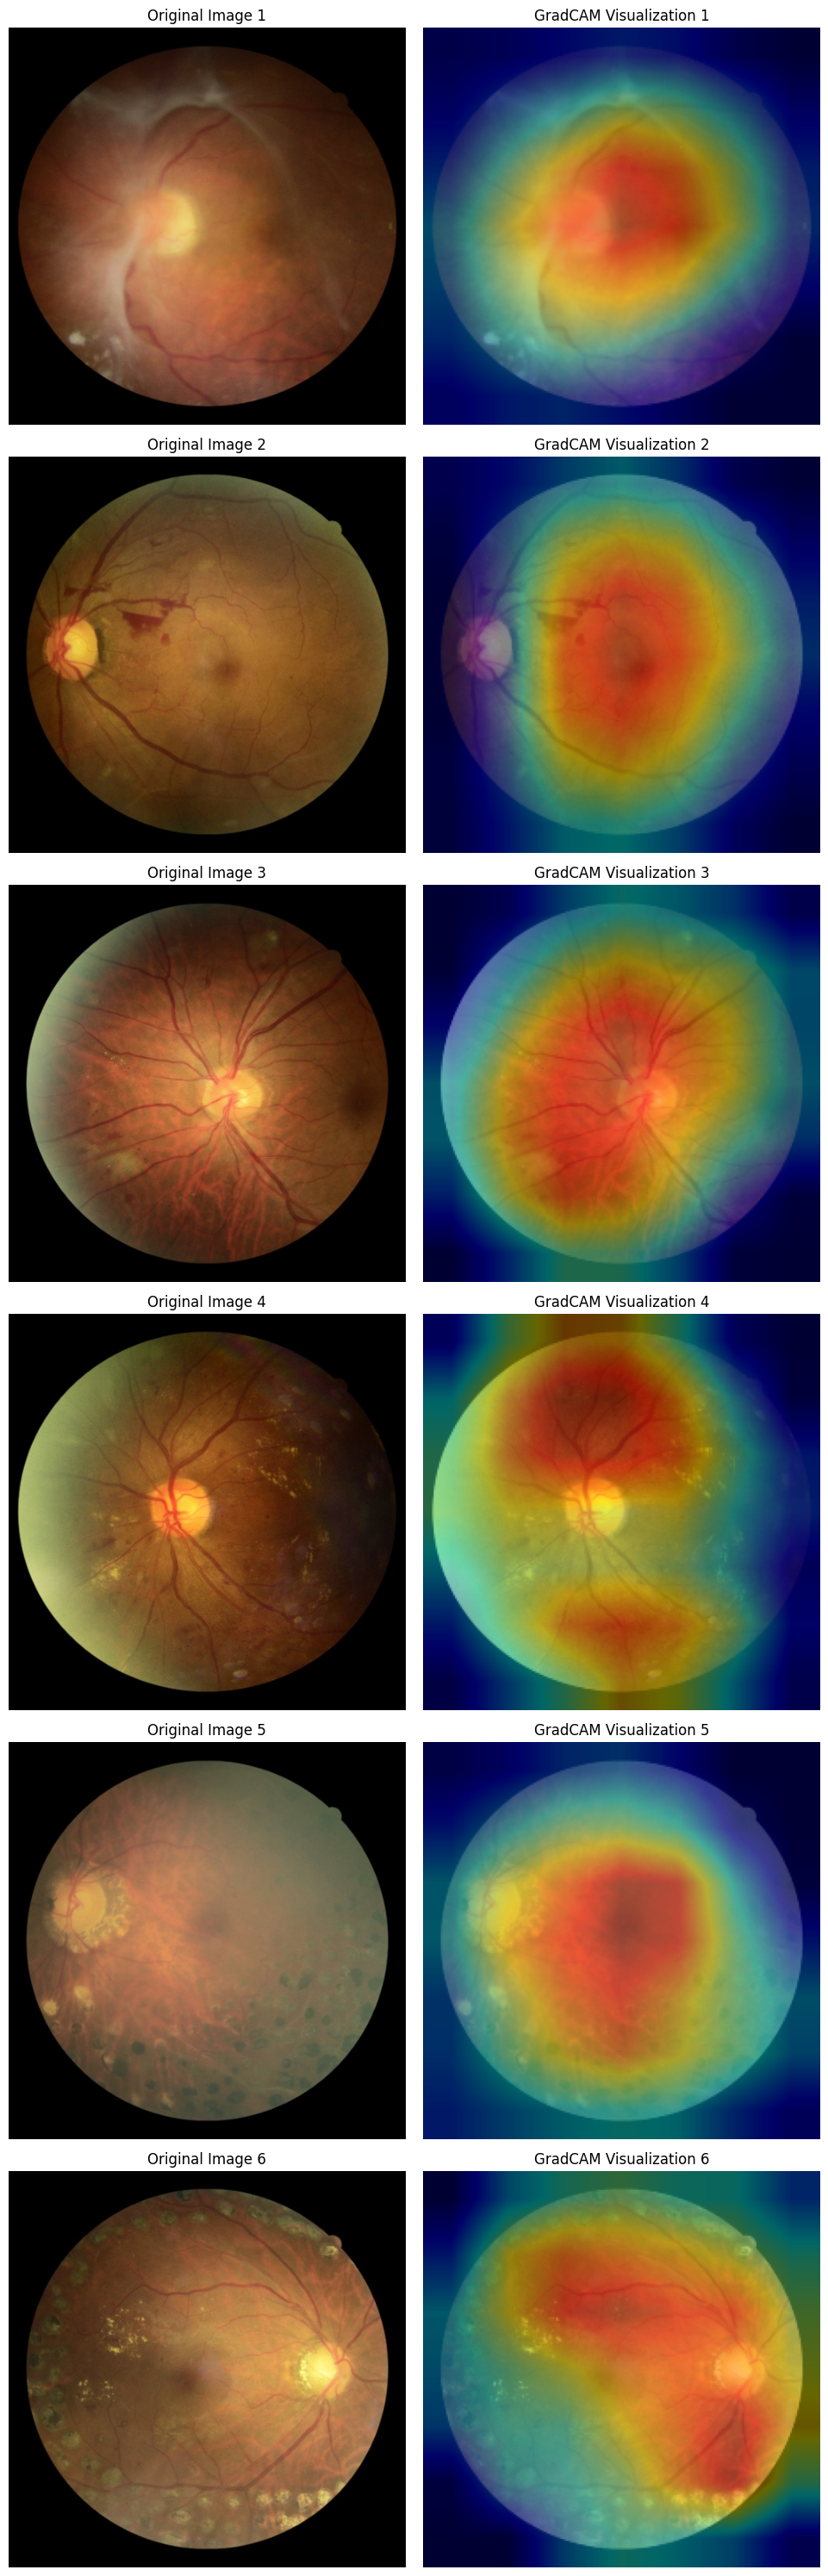

In [ ]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image

# Assuming SingleModels() is already defined
model = SingleModels()
state_dict = torch.load('/content/drive/MyDrive/DL_Project/part_a/aug_resnet34.pth', map_location='cpu')
model.load_state_dict(state_dict, strict=True)
model.eval()

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        target_layer = dict(self.model.named_modules())[self.target_layer]
        target_layer.register_forward_hook(forward_hook)
        target_layer.register_backward_hook(backward_hook)

    def generate_heatmap(self, input_tensor, class_index=None):
        output = self.model(input_tensor)
        if class_index is None:
            class_index = output.argmax(dim=1).item()

        score = output[:, class_index]
        self.model.zero_grad()
        score.backward()

        # Compute Grad-CAM
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # Global average pooling over height and width
        cam = (weights * self.activations).sum(dim=1)  # Weighted sum across channels
        cam = F.relu(cam)  # Apply ReLU
        cam = cam.squeeze().cpu().numpy()  # Remove batch dimension

        # Normalize and resize heatmap
        cam = (cam - cam.min()) / (cam.max() - cam.min())  # Normalize to [0, 1]
        cam = cv2.resize(cam, (224, 224))  # Resize to match input image size
        return cam

# Preprocessing
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Grad-CAM instance
grad_cam = GradCAM(model=model, target_layer='backbone.layer4')

# List of image paths
image_paths = [
    '/content/drive/MyDrive/DL_Project/DeepDRiD/train/87/87_l1.jpg',
    '/content/drive/MyDrive/DL_Project/DeepDRiD/train/55/55_l2.jpg',
    '/content/drive/MyDrive/DL_Project/DeepDRiD/train/123/123_l1.jpg',
    '/content/drive/MyDrive/DL_Project/DeepDRiD/train/220/220_l1.jpg',
    '/content/drive/MyDrive/DL_Project/DeepDRiD/train/213/213_l2.jpg',
    '/content/drive/MyDrive/DL_Project/DeepDRiD/test/366/366_r2.jpg',
]

# Visualization
fig, axs = plt.subplots(len(image_paths), 2, figsize=(10, 5 * len(image_paths)))

for i, image_path in enumerate(image_paths):
    # Load and preprocess image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Image not found at path: {image_path}")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original_image = image.copy()
    image = cv2.resize(image, (224, 224))
    input_tensor = preprocess(image).unsqueeze(0)  # Add batch dimension

    # Generate Grad-CAM heatmap
    heatmap = grad_cam.generate_heatmap(input_tensor)
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)  # Convert to RGB

    # Blend heatmap with original image
    overlay = cv2.addWeighted(image, 0.6, heatmap_color, 0.4, 0)

    # Display original and overlay
    axs[i, 0].imshow(original_image)
    axs[i, 0].set_title(f'Original Image {i+1}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(overlay)
    axs[i, 1].set_title(f'GradCAM Visualization {i+1}')
    axs[i, 1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
Image.fromarray(image).save("original_image.png")
Image.fromarray(overlay).save("GradCAM.png")